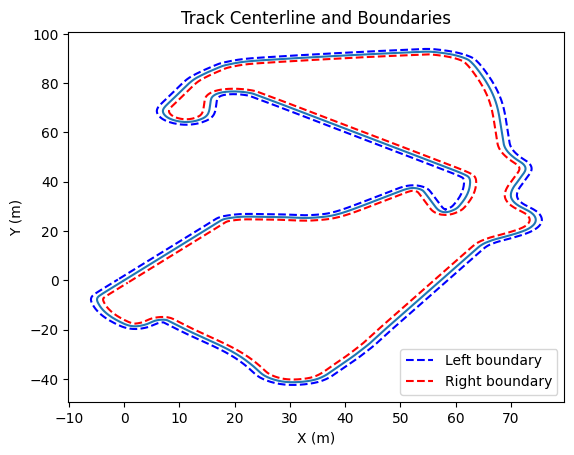

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "splines/Silverstone/Silverstone_centerline.csv"  # path to your CSV
df = pd.read_csv(csv_path, comment='#', header=None)
df.columns = ['x_m', 'y_m', 'w_tr_right_m', 'w_tr_left_m']

# === Extract centerline coordinates ===
x = df['x_m'].values
y = df['y_m'].values
w_r = df['w_tr_right_m'].values
w_l = df['w_tr_left_m'].values

# === Compute tangents and normals ===
# Forward difference (approximate tangent)
dx = np.gradient(x)
dy = np.gradient(y)
dx2 = np.gradient(dx)
dy2 = np.gradient(dy)
norms = np.sqrt(dx**2 + dy**2)
dx /= norms
dy /= norms

# Normal vectors (perpendicular to tangent)
nx = -dy
ny = dx

# === Compute boundary lines ===
left_x = x + nx * w_l
left_y = y + ny * w_l
right_x = x - nx * w_r
right_y = y - ny * w_r

plt.plot(left_x, left_y, 'b--', label='Left boundary')
plt.plot(right_x, right_y, 'r--', label='Right boundary')
plt.plot(x, y)

plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Track Centerline and Boundaries")
plt.legend()

centerline_x = x
centerline_y = y


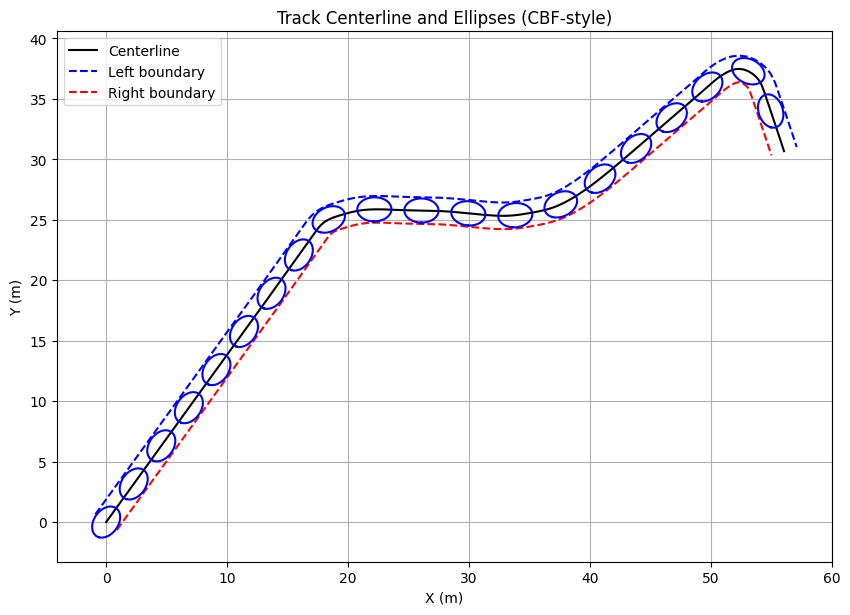

In [3]:
from functions.barrier_functions import *



fig, ax = plt.subplots(figsize=(10, 10))

# Plot centerline and boundaries
ax.plot(centerline_x[:200], centerline_y[:200], 'k-', label='Centerline')
ax.plot(left_x[:200], left_y[:200], 'b--', label='Left boundary')
ax.plot(right_x[:200], right_y[:200], 'r--', label='Right boundary')

for i in range(0, 200, 10):
    x_ = centerline_x[i]
    y_ = centerline_y[i]
    theta = np.arctan2(dy[i], dx[i])  # Ignored for now

    cbf_lambda_x, cbf_lambda_y, cbf_angle = 0.5, 1, np.rad2deg(theta)
    cbf_params1 = {
    "Hh": canonical2D([ cbf_lambda_x , cbf_lambda_y ], cbf_angle),
    "p0": [ x_, y_ ] }
    cbf = ConcaveQuadraticBarrier( hessian = cbf_params1["Hh"], center = cbf_params1["p0"], height = 0.5 ,
                             limits=(x_ - 2, x_ + 2, y_ - 2, y_ + 2), spacing=0.05)
    cbf.plot_levels(ax=ax, levels=[0.0], color='blue', linestyle='-')



ax.set_aspect('equal')
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("Track Centerline and Ellipses (CBF-style)")
ax.legend()
ax.grid(True)
plt.show()

In [4]:
dx = np.gradient(x)
dy = np.gradient(y)
dx2 = np.gradient(dx)
dy2 = np.gradient(dy)

x_ = centerline_x[0]
y_ = centerline_y[0]
theta = np.arctan2(dy[0], dx[0]) 

omega = (dx[0]*dy2[0] -dy[0]*dx2[0])/(dx[0]**2 + dy[0]**2)  

x_1 = x_ +dx[0]
y_1 = y_ +dy[0]
theta_1 = theta + omega
print(x_1,y_1,theta_1)
print(centerline_x[1],centerline_y[1],np.arctan2(dy[1],dx[1]))

    #cbf_lambda_x, cbf_lambda_y, cbf_angle = 0.5, 1, np.rad2deg(theta)
    #H = np.array(canonical2D([ cbf_lambda_x , cbf_lambda_y ], cbf_angle))
    #p0 = np.array([ x_, y_ ])
    #print(f"CBF params at index {i}: H = {H}, p0 = {p0}")

    

0.2280310291062993 0.3151271159628834 0.9444196186151437
0.2280310291062993 0.3151271159628834 0.9444196189054822


In [ ]:
import yaml
from controllers.path import Path
state = np.array([0.5, 0.5])  # Initial state
control = np.array([0.0, 0.0])  # Initial control input
with open("config/config.yaml", 'rb') as f:
    conf = yaml.safe_load(f.read())  # load the config file

path = Path(conf)

H=canonical2D([0.5,1],np.rad2deg(0.5))
p = np.array([0,0])
cbf = ConcaveQuadraticBarrier(hessian=H, center=p, height=1,
                        limits=(0 - 4, 0 + 4, 0 - 4, 0 + 4), spacing=0.05)

point = (np.array([3,0]))
dt = 0.01
p_dot = np.array([2,0])
theta_dot = 10
theta = 0.5
c, s = np.cos(theta), np.sin(theta)
R = np.array(((c,-s),(s,c)))
Omega = np.array([[0, -theta_dot],[theta_dot, 0]])

cbf.set_params(hessian = H, center = p, R= R, omega= Omega, p_dot = p_dot)

h = cbf.function(point)
dh_dt = cbf.time_derivative(point)
print(h+dh_dt*dt)

H=canonical2D([0.5,1],np.rad2deg(theta+theta_dot*dt))
cbf.set_params(hessian = H, center = p+p_dot*dt, R= R, omega = Omega, p_dot = p_dot)
print(cbf.function(point))

-2.230264440486365
-2.4279147746431686


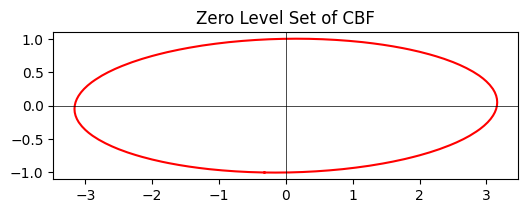

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
cbf.plot_levels(ax=ax, levels=[0], color="red", linewidth=2)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Zero Level Set of CBF")
plt.show()